# 1. Apriori — Introduction & Intuition

Now we move from the fundamentals of Association Rule Learning to the first major algorithm used to find frequent itemsets:

$$
\boxed{\text{Apriori}}
$$

---

## 1.1 What is Apriori?

**Apriori is an algorithm used to find frequent itemsets** in transactional data.

Once frequent itemsets are discovered, they can be used to generate association rules.

The overall process is:

$$
\text{Transactions}
\rightarrow
\boxed{\text{Apriori}}
\rightarrow
\text{Frequent Itemsets}
\rightarrow
\text{Association Rules}
$$

The important distinction is:

> **Apriori primarily finds frequent itemsets.**

The quality of the resulting rules can then be evaluated using measures such as **support, confidence, and lift**.

---

## 1.2 Why Do We Need Apriori?

Suppose we have only four items:

$$
A,B,C,D
$$

We can create:

### 1-itemsets

$$
\{A\},\{B\},\{C\},\{D\}
$$

### 2-itemsets

$$
\{A,B\},\{A,C\},\{A,D\},\{B,C\},\{B,D\},\{C,D\}
$$

### 3-itemsets

$$
\{A,B,C\},\{A,B,D\},\{A,C,D\},\{B,C,D\}
$$

### 4-itemset

$$
\{A,B,C,D\}
$$

The total number of non-empty itemsets is:

$$
2^4-1=15
$$

For four items, this is manageable.

But with 100 different items:

$$
2^{100}-1
$$

possible non-empty itemsets exist.

That's an enormous search space.

We therefore need a way to **avoid checking combinations that cannot possibly be frequent**.

This is the main reason Apriori is useful.

---

# 1.3 The Key Idea Behind Apriori

Apriori is based on one fundamental observation:

> **If an itemset is infrequent, every larger itemset containing it must also be infrequent.**

This is called the:

$$
\boxed{\text{Apriori Principle}}
$$

It is also known as the **downward-closure property**.

This principle allows Apriori to **prune** unnecessary candidates.

---

# 1.4 Understanding the Apriori Principle

Suppose:

$$
\{\text{Milk,Bread}\}
$$

is infrequent.

Now consider the larger itemset:

$$
\{\text{Milk,Bread,Butter}\}
$$

The larger itemset contains:

$$
\{\text{Milk,Bread}\}
$$

For Milk, Bread, and Butter to occur together, Milk and Bread must already occur together.

Therefore, the larger itemset cannot occur more frequently than the smaller one.

So:

$$
\text{Support}(\{\text{Milk,Bread,Butter}\})
\leq
\text{Support}(\{\text{Milk,Bread}\})
$$

Therefore, if:

$$
\{\text{Milk,Bread}\}
$$

is already below the minimum support threshold, there is no reason to investigate:

$$
\{\text{Milk,Bread,Butter}\}
$$

or any other larger itemset containing Milk and Bread.

---

# 1.5 Why Does This Work?

Suppose we have 100 transactions.

Imagine:

$$
\{\text{A,B}\}
$$

appears in 10 transactions.

Now consider:

$$
\{\text{A,B,C}\}
$$

Every transaction containing A, B, and C must also contain A and B.

Therefore, the number of transactions containing:

$$
\{\text{A,B,C}\}
$$

can never exceed 10.

So:

$$
\text{Support}(\{A,B,C\})
\leq
\text{Support}(\{A,B\})
$$

More generally, if:

$$
X\subseteq Y
$$

then:

$$
\boxed{
\text{Support}(Y)\leq\text{Support}(X)
}
$$

This property is what makes Apriori's pruning possible.

---

# 1.6 Numerical Example

Suppose:

$$
\text{Total transactions}=100
$$

and the minimum support is:

$$
40\%
$$

Now suppose:

$$
\text{Support}(\{A,B\})=30\%
$$

Since:

$$
30\%<40\%
$$

the itemset:

$$
\{A,B\}
$$

is **infrequent**.

Now consider:

$$
\{A,B,C\}
$$

Because:

$$
\{A,B\}\subseteq\{A,B,C\}
$$

we know:

$$
\text{Support}(\{A,B,C\})
\leq30\%
$$

Therefore:

$$
\text{Support}(\{A,B,C\})<40\%
$$

So we don't need to calculate its exact support.

We can immediately **prune** it.

This is the major efficiency improvement provided by Apriori.

---

# 1.7 Apriori Works Level by Level

Apriori doesn't try to generate every possible itemset at once.

It works progressively:

$$
1\text{-itemsets}
\rightarrow
2\text{-itemsets}
\rightarrow
3\text{-itemsets}
\rightarrow
4\text{-itemsets}
\rightarrow\cdots
$$

At each level, it:

1. Generates candidate itemsets.
2. Calculates their support.
3. Removes infrequent itemsets.
4. Uses the remaining frequent itemsets to create larger candidates.

The process can be represented as:

$$
L_1
\rightarrow
C_2
\rightarrow
L_2
\rightarrow
C_3
\rightarrow
L_3
\rightarrow
\cdots
$$

where:

* $C_k$ = candidate $k$-itemsets
* $L_k$ = frequent $k$-itemsets

---

# 1.8 The Core Strategy

The entire idea can be reduced to three steps:

$$
\boxed{
\text{Find small frequent itemsets}
}
$$

then:

$$
\boxed{
\text{Use them to generate larger candidates}
}
$$

and:

$$
\boxed{
\text{Prune candidates containing infrequent subsets}
}
$$

This allows Apriori to avoid exploring a huge number of impossible combinations.

---

# 1.9 Mental Model

Think of Apriori like this:

> **If a smaller combination isn't frequent enough, adding more items can never make that combination frequent.**

For example:

$$
\{A,B\}\text{ is infrequent}
$$

therefore:

$$
\{A,B,C\}
$$

$$
\{A,B,D\}
$$

$$
\{A,B,C,D\}
$$

and every other larger itemset containing ${A,B}$ can be eliminated.

That **pruning principle** is the heart of Apriori.


# 2. Apriori — Complete Algorithm

Now let's move from the **intuition** to exactly **how Apriori operates**.

The main idea is:

$$
\text{Generate}
\rightarrow
\text{Count Support}
\rightarrow
\text{Prune}
\rightarrow
\text{Generate Larger Itemsets}
$$

Apriori repeats this process until no more frequent itemsets can be found.

---

## 2.1 Important Notation

Before the algorithm, let's establish two terms.

### Candidate Itemsets

We use:

$$
C_k
$$

to represent the set of **candidate $k$-itemsets**.

For example:

$$
C_1
$$

contains candidate 1-itemsets.

$$
C_2
$$

contains candidate 2-itemsets.

---

### Frequent Itemsets

We use:

$$
L_k
$$

to represent the set of **frequent $k$-itemsets**.

For example:

$$
L_1
$$

contains frequent 1-itemsets.

$$
L_2
$$

contains frequent 2-itemsets.

Therefore:

$$
C_k
\rightarrow
\text{Support Filtering}
\rightarrow
L_k
$$

---

# 2.2 Step 1 — Find Frequent 1-Itemsets

First, Apriori looks at individual items.

Suppose our transactions are:

| Transaction | Items   |
| ----------- | ------- |
| T1          | A, B, C |
| T2          | A, B    |
| T3          | A, C    |
| T4          | B, C    |
| T5          | A, B, C |

Suppose:

$$
\text{Minimum Support}=40\%
$$

There are 5 transactions.

First, count each individual item.

### A

Appears in:

$$
T_1,T_2,T_3,T_5
$$

So:

$$
\text{Support}(A)=\frac{4}{5}=80\%
$$

### B

Appears in:

$$
T_1,T_2,T_4,T_5
$$

So:

$$
\text{Support}(B)=\frac{4}{5}=80\%
$$

### C

Appears in:

$$
T_1,T_3,T_4,T_5
$$

So:

$$
\text{Support}(C)=\frac{4}{5}=80\%
$$

Therefore:

$$
L_1=
\{\{A\},\{B\},\{C\}\}
$$

All three are frequent.

---

# 2.3 Step 2 — Generate Candidate 2-Itemsets

Now Apriori uses the frequent 1-itemsets to generate possible 2-itemsets.

From:

$$
L_1=
\{\{A\},\{B\},\{C\}\}
$$

we generate:

$$
C_2=
\{
\{A,B\},
\{A,C\},
\{B,C\}
\}
$$

These are **candidates**.

We haven't yet determined whether they are frequent.

---

# 2.4 Step 3 — Calculate Support

Now we scan the transactions.

### {A,B}

Appears in:

$$
T_1,T_2,T_5
$$

Therefore:

$$
\text{Support}(A,B)
=
\frac{3}{5}
=
60\%
$$

### {A,C}

Appears in:

$$
T_1,T_3,T_5
$$

Therefore:

$$
\text{Support}(A,C)
=
\frac{3}{5}
=
60\%
$$

### {B,C}

Appears in:

$$
T_1,T_4,T_5
$$

Therefore:

$$
\text{Support}(B,C)
=
\frac{3}{5}
=
60\%
$$

Since the minimum support is:

$$
40\%
$$

all three survive.

Therefore:

$$
L_2=
\{
\{A,B\},
\{A,C\},
\{B,C\}
\}
$$

---

# 2.5 Step 4 — Generate Candidate 3-Itemsets

Now we use the frequent 2-itemsets to create 3-itemset candidates.

From:

$$
L_2=
\{
\{A,B\},
\{A,C\},
\{B,C\}
\}
$$

we can generate:

$$
C_3=
\{
\{A,B,C\}
\}
$$

There is only one possible 3-itemset.

---

# 2.6 Step 5 — Apply the Apriori Principle

Before calculating support for:

$$
\{A,B,C\}
$$

Apriori checks its smaller subsets.

The 2-item subsets are:

$$
\{A,B\}
$$

$$
\{A,C\}
$$

$$
\{B,C\}
$$

All three are in:

$$
L_2
$$

Therefore, the candidate survives the pruning step.

Now we calculate its support.

---

# 2.7 Step 6 — Calculate Support of the 3-Itemset

The itemset:

$$
\{A,B,C\}
$$

appears in:

$$
T_1,T_5
$$

Therefore:

$$
\text{Support}(A,B,C)
=
\frac{2}{5}
=
40\%
$$

Since:

$$
40\%\geq40\%
$$

it is frequent.

Therefore:

$$
L_3=
\{
\{A,B,C\}
\}
$$

---

# 2.8 Step 7 — Try to Generate Larger Itemsets

Now Apriori attempts to create:

$$
C_4
$$

But there are only three different items:

$$
A,B,C
$$

So a 4-itemset cannot be formed.

The algorithm stops.

Our final frequent itemsets are:

### 1-itemsets

$$
L_1=
\{
\{A\},
\{B\},
\{C\}
\}
$$

### 2-itemsets

$$
L_2=
\{
\{A,B\},
\{A,C\},
\{B,C\}
\}
$$

### 3-itemsets

$$
L_3=
\{
\{A,B,C\}
\}
$$

---

# 2.9 Complete Apriori Flow

The whole process can now be represented as:

$$
C_1
\rightarrow
\text{Support Count}
\rightarrow
L_1
$$

then:

$$
L_1
\rightarrow
\text{Candidate Generation}
\rightarrow
C_2
$$

then:

$$
C_2
\rightarrow
\text{Support Count + Pruning}
\rightarrow
L_2
$$

then:

$$
L_2
\rightarrow
\text{Candidate Generation + Pruning}
\rightarrow
C_3
$$

then:

$$
C_3
\rightarrow
\text{Support Count}
\rightarrow
L_3
$$

and this continues until no more candidates can be generated.

---

# 2.10 The Algorithm in Simple Words

Apriori essentially does this:

```text
Start with individual items
        ↓
Find frequent items
        ↓
Create pairs from frequent items
        ↓
Remove infrequent pairs
        ↓
Create larger combinations
        ↓
Prune combinations containing
infrequent subsets
        ↓
Repeat
        ↓
No more candidates
        ↓
Final frequent itemsets
```

The two operations you'll see repeatedly are:

$$
\boxed{\text{Candidate Generation}}
$$

and:

$$
\boxed{\text{Candidate Pruning}}
$$

Understanding these two operations is essential before we go deeper into the **candidate generation and pruning mechanics**.

# 3. Candidate Generation and Pruning

The most important part of Apriori's efficiency is **how it generates candidates and removes impossible ones**.

There are two main operations:

$$
\boxed{
\text{Join}
\rightarrow
\text{Prune}
}
$$

---

## 3.1 Candidate Generation

Suppose we already know the frequent 2-itemsets:

$$
L_2=
\{
\{A,B\},
\{A,C\},
\{B,C\},
\{B,D\}
\}
$$

We want to generate candidate 3-itemsets.

Apriori tries to combine compatible frequent itemsets.

For example:

$$
\{A,B\}+\{A,C\}
\rightarrow
\{A,B,C\}
$$

Similarly:

$$
\{A,B\}+\{B,C\}
\rightarrow
\{A,B,C\}
$$

and:

$$
\{B,C\}+\{B,D\}
\rightarrow
\{B,C,D\}
$$

The resulting combinations become candidates for $C_3$.

---

# 3.2 Why Can't We Just Combine Everything?

Because not every generated combination can possibly be frequent.

Suppose we have:

$$
L_2=
\{
\{A,B\},
\{A,C\},
\{B,C\},
\{B,D\}
\}
$$

Consider the possible candidate:

$$
\{A,B,D\}
$$

Its 2-item subsets are:

$$
\{A,B\}
$$

$$
\{A,D\}
$$

$$
\{B,D\}
$$

We know:

$$
\{A,B\}\in L_2
$$

and:

$$
\{B,D\}\in L_2
$$

but:

$$
\{A,D\}\notin L_2
$$

That means ${A,D}$ was **not frequent**.

Therefore, according to the Apriori Principle:

$$
\boxed{
\{A,B,D\}\text{ cannot be frequent}
}
$$

So Apriori **prunes** it before calculating its support.

---

# 3.3 The Pruning Rule

When considering a candidate $k$-itemset:

> **Every $(k-1)$-item subset of that candidate must be frequent.**

If even **one** of those subsets is infrequent, discard the candidate.

For a candidate:

$$
\{A,B,C\}
$$

the 2-item subsets are:

$$
\{A,B\},\{A,C\},\{B,C\}
$$

All must be frequent.

If:

$$
\{A,C\}
$$

is infrequent:

$$
\boxed{
\{A,B,C\}\text{ is pruned}
}
$$

We don't need to calculate its support.

---

# 3.4 Why Pruning Saves Computation

Imagine there are many items.

Without pruning:

$$
\text{Generate candidate}
\rightarrow
\text{Scan database}
\rightarrow
\text{Calculate support}
$$

for every possible combination.

With Apriori:

$$
\text{Generate candidate}
\rightarrow
\boxed{\text{Check subsets}}
\rightarrow
\text{Discard impossible candidates}
\rightarrow
\text{Calculate support only for survivors}
$$

This can eliminate a huge number of unnecessary database scans and support calculations.

---

# 3.5 Complete Small Example

Suppose:

$$
L_2=
\{
\{A,B\},
\{A,C\},
\{B,C\},
\{B,D\}
\}
$$

We want to find $C_3$.

Potential candidates include:

$$
\{A,B,C\}
$$

and:

$$
\{A,B,D\}
$$

and:

$$
\{B,C,D\}
$$

Now apply pruning.

### Candidate 1

$$
\{A,B,C\}
$$

Subsets:

$$
\{A,B\},\{A,C\},\{B,C\}
$$

All are in $L_2$.

Therefore:

$$
\boxed{\{A,B,C\}\text{ survives}}
$$

---

### Candidate 2

$$
\{A,B,D\}
$$

Subsets:

$$
\{A,B\},\{A,D\},\{B,D\}
$$

But:

$$
\{A,D\}\notin L_2
$$

Therefore:

$$
\boxed{\{A,B,D\}\text{ is pruned}}
$$

---

### Candidate 3

$$
\{B,C,D\}
$$

Subsets:

$$
\{B,C\},\{B,D\},\{C,D\}
$$

But:

$$
\{C,D\}\notin L_2
$$

Therefore:

$$
\boxed{\{B,C,D\}\text{ is pruned}}
$$

So after pruning:

$$
C_3=
\{
\{A,B,C\}
\}
$$

Only this candidate needs its support calculated.

---

# 3.6 Join → Prune → Support

This gives us the central mechanism of Apriori:

$$
\boxed{
L_{k-1}
\rightarrow
\text{Join}
\rightarrow
C_k
\rightarrow
\text{Prune}
\rightarrow
\text{Support Counting}
\rightarrow
L_k
}
$$

This repeats for:

$$
k=2,3,4,\ldots
$$

until no more frequent itemsets can be generated.

---

# 3.7 Important Distinction

Don't confuse **candidate generation** with **support counting**.

### Candidate generation

Creates combinations that **might** be frequent.

$$
L_{k-1}\rightarrow C_k
$$

### Pruning

Removes candidates that **cannot** be frequent.

$$
C_k\rightarrow C_k'
$$

### Support counting

Checks the remaining candidates against the actual transactions.

$$
C_k'\rightarrow L_k
$$

So Apriori doesn't assume a candidate is frequent just because it was generated.

It first creates it, then checks whether it deserves to survive.

---

# 3.8 The Core Idea

The whole candidate-generation/pruning mechanism can be remembered as:

$$
\boxed{
\text{Generate possibilities}
\rightarrow
\text{Eliminate impossible ones}
\rightarrow
\text{Count actual occurrences}
}
$$

This is what allows Apriori to search through a massive itemset space without examining every possible combination.


**`02_Apriori.ipynb`**

# 4. Apriori — Complete Numerical Dry Run

Now let's run Apriori **completely by hand** on a small transaction dataset.

This will connect:

* candidate generation
* support counting
* pruning
* frequent itemsets

into one complete process.

---

## 4.1 Dataset

Suppose we have these 5 transactions:

| Transaction | Items   |
| ----------- | ------- |
| T1          | A, B, C |
| T2          | A, B    |
| T3          | A, C    |
| T4          | B, C    |
| T5          | A, B, C |

Set:

$$
\text{Minimum Support}=40\%
$$

Since we have 5 transactions:

$$
40\%\times5=2
$$

Therefore, an itemset must appear in **at least 2 transactions** to be considered frequent.

---

# 4.2 Step 1 — Generate $C_1$

Start with individual items:

$$
C_1=
\{
\{A\},
\{B\},
\{C\}
\}
$$

Now count their occurrences.

### A

A appears in:

$$
T_1,T_2,T_3,T_5
$$

Count:

$$
4
$$

Support:

$$
\frac{4}{5}=80\%
$$

### B

B appears in:

$$
T_1,T_2,T_4,T_5
$$

Count:

$$
4
$$

Support:

$$
\frac{4}{5}=80\%
$$

### C

C appears in:

$$
T_1,T_3,T_4,T_5
$$

Count:

$$
4
$$

Support:

$$
\frac{4}{5}=80\%
$$

Therefore:

$$
L_1=
\{
\{A\},
\{B\},
\{C\}
\}
$$

All three are frequent.

---

# 4.3 Step 2 — Generate $C_2$

Use the frequent 1-itemsets to create pairs.

From:

$$
L_1=
\{
\{A\},\{B\},\{C\}
\}
$$

we generate:

$$
C_2=
\{
\{A,B\},
\{A,C\},
\{B,C\}
\}
$$

Now count each pair.

---

### ${A,B}$

Appears in:

$$
T_1,T_2,T_5
$$

Count:

$$
3
$$

Support:

$$
\frac{3}{5}=60\%
$$

Therefore:

$$
\{A,B\}\in L_2
$$

---

### ${A,C}$

Appears in:

$$
T_1,T_3,T_5
$$

Count:

$$
3
$$

Support:

$$
\frac{3}{5}=60\%
$$

Therefore:

$$
\{A,C\}\in L_2
$$

---

### ${B,C}$

Appears in:

$$
T_1,T_4,T_5
$$

Count:

$$
3
$$

Support:

$$
\frac{3}{5}=60\%
$$

Therefore:

$$
\{B,C\}\in L_2
$$

So:

$$
L_2=
\{
\{A,B\},
\{A,C\},
\{B,C\}
\}
$$

---

# 4.4 Step 3 — Generate $C_3$

Now use $L_2$ to create 3-itemset candidates.

We have:

$$
\{A,B\}
$$

$$
\{A,C\}
$$

$$
\{B,C\}
$$

The possible 3-itemset is:

$$
C_3=
\{
\{A,B,C\}
\}
$$

---

# 4.5 Step 4 — Prune $C_3$

Before counting its support, Apriori checks all 2-item subsets.

For:

$$
\{A,B,C\}
$$

the subsets are:

$$
\{A,B\}
$$

$$
\{A,C\}
$$

$$
\{B,C\}
$$

All three are present in:

$$
L_2
$$

Therefore, the candidate survives pruning.

---

# 4.6 Step 5 — Count Support of ${A,B,C}$

The combination:

$$
\{A,B,C\}
$$

appears in:

$$
T_1,T_5
$$

Count:

$$
2
$$

Support:

$$
\frac{2}{5}=40\%
$$

Our minimum support is:

$$
40\%
$$

Therefore:

$$
40\%\geq40\%
$$

So:

$$
\boxed{
\{A,B,C\}\in L_3
}
$$

---

# 4.7 Step 6 — Try $C_4$

We now have:

$$
L_3=
\{
\{A,B,C\}
\}
$$

But there are only three unique items:

$$
A,B,C
$$

Therefore, we cannot create a 4-itemset.

The algorithm terminates.

---

# 4.8 Final Frequent Itemsets

### $L_1$

$$
\{
\{A\},
\{B\},
\{C\}
\}
$$

### $L_2$

$$
\{
\{A,B\},
\{A,C\},
\{B,C\}
\}
$$

### $L_3$

$$
\{
\{A,B,C\}
\}
$$

These are the **frequent itemsets discovered by Apriori**.

---

# 4.9 Complete Dry Run in One View

| Stage | Candidates          | Result       |
| ----- | ------------------- | ------------ |
| $C_1$ | {A}, {B}, {C}       | All frequent |
| $C_2$ | {A,B}, {A,C}, {B,C} | All frequent |
| $C_3$ | {A,B,C}             | Frequent     |
| $C_4$ | None possible       | Stop         |

The flow is:

$$
C_1
\rightarrow
L_1
\rightarrow
C_2
\rightarrow
L_2
\rightarrow
C_3
\rightarrow
L_3
\rightarrow
\text{Stop}
$$

---

# 4.10 Where Did Pruning Actually Matter?

In this particular example, **nothing was pruned**, because every smaller itemset happened to be frequent.

To see pruning in action, imagine:

$$
\{B,C\}
$$

had been infrequent.

Then when Apriori considered:

$$
\{A,B,C\}
$$

it would check:

$$
\{A,B\},\{A,C\},\{B,C\}
$$

Since:

$$
\{B,C\}\notin L_2
$$

Apriori would immediately discard:

$$
\boxed{\{A,B,C\}}
$$

without calculating its support.

That's the key optimization we studied earlier.

---

# 4.11 What Apriori Has Actually Done

Notice the progression:

$$
\boxed{
\text{Individual Items}
}
$$

↓

$$
\boxed{
\text{Pairs}
}
$$

↓

$$
\boxed{
\text{Triplets}
}
$$

↓

$$
\boxed{
\text{Frequent Itemsets}
}
$$

At every level, Apriori asks:

> **Can this combination still possibly be frequent?**

If yes → continue.

If no → **prune it**.

That is the fundamental behavior of the algorithm.


# 5. Apriori — Candidate Generation in Detail

We have seen the complete dry run. Now let's understand **exactly how Apriori creates larger candidate itemsets from smaller frequent itemsets**.

This process is called the **Join Step**.

---

## 5.1 Why Do We Need Candidate Generation?

Suppose we already found:

$$
L_2=
\{
\{A,B\},
\{A,C\},
\{A,D\},
\{B,C\},
\{B,D\}
\}
$$

These are all frequent 2-itemsets.

Now we want to find frequent 3-itemsets.

We need to construct possible 3-itemsets from these known frequent pairs.

This produces:

$$
L_2
\rightarrow
C_3
$$

---

# 5.2 The Basic Join Idea

Two frequent $(k-1)$-itemsets can be joined if their first $k-2$ items are the same.

For example:

$$
\{A,B\}
$$

and:

$$
\{A,C\}
$$

have the common prefix:

$$
A
$$

So they can be joined:

$$
\{A,B\}\cup\{A,C\}
=
\{A,B,C\}
$$

Therefore:

$$
\{A,B\}+\{A,C\}
\rightarrow
\{A,B,C\}
$$

---

## 5.3 Another Example

Consider:

$$
\{A,B\}
$$

and:

$$
\{A,D\}
$$

They also share:

$$
A
$$

So:

$$
\{A,B\}+\{A,D\}
\rightarrow
\{A,B,D\}
$$

This becomes a candidate 3-itemset.

---

# 5.4 When Can't Two Itemsets Be Joined?

Consider:

$$
\{A,B\}
$$

and:

$$
\{C,D\}
$$

They don't share the required prefix.

Joining them would produce:

$$
\{A,B,C,D\}
$$

which is a **4-itemset**, not the required 3-itemset.

Therefore, they aren't joined when generating $C_3$.

The join step is controlled so that we generate itemsets of exactly the desired size.

---

# 5.5 Example of Generating $C_3$

Suppose:

$$
L_2=
\{
\{A,B\},
\{A,C\},
\{A,D\},
\{B,C\},
\{B,D\},
\{C,D\}
\}
$$

Possible joins include:

$$
\{A,B\}+\{A,C\}
\rightarrow
\{A,B,C\}
$$

$$
\{A,B\}+\{A,D\}
\rightarrow
\{A,B,D\}
$$

$$
\{A,C\}+\{A,D\}
\rightarrow
\{A,C,D\}
$$

$$
\{B,C\}+\{B,D\}
\rightarrow
\{B,C,D\}
$$

So we obtain:

$$
C_3=
\{
\{A,B,C\},
\{A,B,D\},
\{A,C,D\},
\{B,C,D\}
\}
$$

These are **candidate** 3-itemsets.

They are not necessarily frequent yet.

---

# 5.6 Then Comes Pruning

Now Apriori checks every $(k-1)$-subset of each candidate.

Consider:

$$
\{A,B,D\}
$$

Its 2-item subsets are:

$$
\{A,B\},\{A,D\},\{B,D\}
$$

If all three are frequent, the candidate survives.

But suppose:

$$
\{A,D\}
$$

was not frequent.

Then:

$$
\{A,B,D\}
$$

must be discarded.

Why?

Because:

$$
\{A,D\}\subseteq\{A,B,D\}
$$

and an infrequent subset means the larger itemset cannot be frequent.

---

# 5.7 Join vs Prune

These are two separate operations.

### Join

Creates possible larger itemsets:

$$
L_{k-1}
\rightarrow
C_k
$$

### Prune

Removes candidates containing an infrequent subset:

$$
C_k
\rightarrow
C_k'
$$

Then support is calculated for the candidates that survive:

$$
C_k'
\rightarrow
L_k
$$

Therefore:

$$
\boxed{
L_{k-1}
\rightarrow
\text{Join}
\rightarrow
C_k
\rightarrow
\text{Prune}
\rightarrow
\text{Support Count}
\rightarrow
L_k
}
$$

---

# 5.8 Why Apriori Doesn't Just Generate Every Combination

Suppose we have 10 items.

There are many possible 3-itemsets.

But if Apriori already knows that:

$$
\{A,B\}
$$

is infrequent, then every candidate containing A and B can immediately be eliminated:

$$
\{A,B,C\}
$$

$$
\{A,B,D\}
$$

$$
\{A,B,E\}
$$

and so on.

So Apriori uses information from **smaller itemsets to control the search for larger itemsets**.

That's what makes the algorithm practical compared with blindly testing every combination.


# 6. Apriori — Support Counting

Now we need to understand how Apriori actually determines whether a candidate itemset is frequent.

This is done through **support counting**.

---

## 6.1 What is Support Counting?

Suppose Apriori has generated this candidate:

$$
\{A,B\}
$$

It needs to determine:

> How many transactions contain both A and B?

It scans the transactions and counts every transaction that contains the **entire itemset**.

Then:

$$
\text{Support}(A,B)
=
\frac{\text{Count}(A,B)}
{\text{Total Transactions}}
$$

---

## 6.2 Example

Suppose we have:

| Transaction | Items   |
| ----------- | ------- |
| T1          | A, B, C |
| T2          | A, B    |
| T3          | A, C    |
| T4          | B, C    |
| T5          | A, B, C |

Candidate:

$$
\{A,B\}
$$

Check every transaction:

| Transaction | Contains A and B? |
| ----------- | ----------------- |
| T1          | Yes               |
| T2          | Yes               |
| T3          | No                |
| T4          | No                |
| T5          | Yes               |

Therefore:

$$
\text{Count}(A,B)=3
$$

There are 5 transactions:

$$
\text{Support}(A,B)
=
\frac{3}{5}
=
60\%
$$

---

# 6.3 Support Counting for Larger Itemsets

The same process works for any size.

Suppose the candidate is:

$$
\{A,B,C\}
$$

We need a transaction containing **all three** items.

Using the same dataset:

| Transaction | Contains A, B, C? |
| ----------- | ----------------- |
| T1          | Yes               |
| T2          | No                |
| T3          | No                |
| T4          | No                |
| T5          | Yes               |

Therefore:

$$
\text{Count}(A,B,C)=2
$$

and:

$$
\text{Support}(A,B,C)
=
\frac{2}{5}
=
40\%
$$

---

# 6.4 Why "All Items" Matters

Suppose we are counting:

$$
\{A,B,C\}
$$

A transaction containing only:

$$
A,B
$$

does **not** count.

A transaction containing:

$$
A,C
$$

does **not** count.

A transaction containing:

$$
B,C
$$

does **not** count.

Only a transaction containing:

$$
A,B,C
$$

counts.

So:

> **An itemset occurs in a transaction only when every item in the itemset is present.**

---

# 6.5 Support Count vs Support

These are related but different.

### Support Count

The actual number of transactions containing the itemset.

For example:

$$
\text{Support Count}(A,B)=3
$$

### Support

The proportion of all transactions containing the itemset.

$$
\text{Support}(A,B)
=
\frac{3}{5}
=
60\%
$$

So:

$$
\boxed{
\text{Support}
=
\frac{\text{Support Count}}
{\text{Total Transactions}}
}
$$

---

# 6.6 Minimum Support

After calculating support, Apriori compares it against the minimum support threshold.

Suppose:

$$
\text{Minimum Support}=40\%
$$

and:

$$
\text{Support}(A,B)=60\%
$$

Then:

$$
60\%\geq40\%
$$

so:

$$
\boxed{\{A,B\}\text{ is frequent}}
$$

But if:

$$
\text{Support}(A,B)=20\%
$$

then:

$$
20\%<40\%
$$

so:

$$
\boxed{\{A,B\}\text{ is infrequent}}
$$

and it is removed.

---

# 6.7 Minimum Support as a Filter

The process is:

$$
\text{Candidate Itemset}
\rightarrow
\text{Count Occurrences}
\rightarrow
\text{Calculate Support}
\rightarrow
\text{Compare with Minimum Support}
$$

Then:

$$
\begin{cases}
\text{Support}\geq\text{Minimum Support}
&\rightarrow \text{Frequent}\\
\text{Support}<\text{Minimum Support}
&\rightarrow \text{Discard}
\end{cases}
$$

This is how Apriori builds:

$$
L_k
$$

from:

$$
C_k
$$

---

# 6.8 Why Support Counting Can Be Expensive

There is an important computational problem here.

Suppose we have:

* millions of transactions
* thousands of candidate itemsets

Apriori may need to repeatedly check whether candidates occur in transactions.

So although **pruning reduces the search space**, support counting can still be expensive.

This is one of the major weaknesses of Apriori.

It is also one of the reasons why **FP-Growth** was developed.

FP-Growth tries to find frequent itemsets without repeatedly generating and testing such a large number of candidate itemsets.


# 7. Apriori — Minimum Support and Its Effect

We have seen that Apriori uses **minimum support** to decide whether an itemset is frequent.

Now let's understand how changing this threshold affects the algorithm.

---

## 7.1 What is Minimum Support?

**Minimum support** is the minimum frequency an itemset must have to be considered frequent.

Suppose:

$$
\text{Minimum Support}=40\%
$$

Then an itemset must appear in at least 40% of transactions.

The decision is:

$$
\boxed{
\text{Support}\geq\text{Minimum Support}
\rightarrow
\text{Frequent}
}
$$

and:

$$
\boxed{
\text{Support}<\text{Minimum Support}
\rightarrow
\text{Infrequent}
}
$$

---

# 7.2 Numerical Example

Suppose there are:

$$
100
$$

transactions.

Consider these itemsets:

| Itemset | Occurrences | Support |
| ------- | ----------: | ------: |
| {A}     |          80 |     80% |
| {B}     |          70 |     70% |
| {A,B}   |          50 |     50% |
| {A,C}   |          30 |     30% |
| {B,C}   |          10 |     10% |

Suppose:

$$
\text{Minimum Support}=40\%
$$

Then:

$$
\{A\},\{B\},\{A,B\}
$$

are frequent.

But:

$$
\{A,C\},\{B,C\}
$$

are discarded.

Therefore:

$$
L=
\{
\{A\},
\{B\},
\{A,B\}
\}
$$

---

# 7.3 What Happens If We Increase Minimum Support?

Suppose we change:

$$
40\%\rightarrow60\%
$$

Now:

* {A} → 80% → frequent
* {B} → 70% → frequent
* {A,B} → 50% → **infrequent**

Therefore:

$$
L=
\{
\{A\},
\{B\}
\}
$$

A higher minimum support means **fewer itemsets survive**.

---

# 7.4 What Happens If We Decrease Minimum Support?

Suppose we instead use:

$$
10\%
$$

Now:

* {A} → 80%
* {B} → 70%
* {A,B} → 50%
* {A,C} → 30%
* {B,C} → 10%

All of these satisfy:

$$
\text{Support}\geq10\%
$$

Therefore, more itemsets survive.

So:

$$
\boxed{
\text{Lower Minimum Support}
\rightarrow
\text{More Frequent Itemsets}
}
$$

and:

$$
\boxed{
\text{Higher Minimum Support}
\rightarrow
\text{Fewer Frequent Itemsets}
}
$$

---

# 7.5 Why Does This Matter Computationally?

This directly affects the amount of work Apriori has to perform.

### High minimum support

Fewer itemsets survive:

$$
\text{High Threshold}
\rightarrow
\text{More Pruning}
\rightarrow
\text{Fewer Candidates}
\rightarrow
\text{Less Computation}
$$

### Low minimum support

More itemsets survive:

$$
\text{Low Threshold}
\rightarrow
\text{Less Pruning}
\rightarrow
\text{More Candidates}
\rightarrow
\text{More Computation}
$$

So minimum support isn't just a statistical parameter.

It also affects **Apriori's computational cost**.

---

# 7.6 Choosing the Threshold

There is no universal value such as:

> "Always use 40%."

The appropriate threshold depends on the dataset.

For example, with a very large transaction database, an itemset with:

$$
1\%
$$

support could still represent thousands of transactions.

In another dataset, 1% might be too rare to be useful.

So the threshold should depend on:

* Dataset size
* Number of items
* How rare useful patterns are
* Business/application requirements
* Computational resources

---

# 7.7 Support Count Version

Sometimes minimum support is expressed as a **minimum support count** instead of a percentage.

Suppose:

$$
\text{Total Transactions}=500
$$

and:

$$
\text{Minimum Support}=10\%
$$

Then the minimum support count is:

$$
500\times0.10=50
$$

Therefore, an itemset must appear in at least:

$$
\boxed{50\text{ transactions}}
$$

to be considered frequent.

The conversion is:

$$
\boxed{
\text{Minimum Support Count}
=
\text{Minimum Support}\times\text{Number of Transactions}
}
$$

---

# 7.8 Important Relationship

Remember this relationship:

$$
\boxed{
\text{Higher Minimum Support}
\rightarrow
\text{Fewer Frequent Itemsets}
\rightarrow
\text{Faster Apriori}
}
$$

while:

$$
\boxed{
\text{Lower Minimum Support}
\rightarrow
\text{More Frequent Itemsets}
\rightarrow
\text{Slower Apriori}
}
$$

But lowering the threshold can also uncover **rare but potentially interesting patterns**.

So choosing minimum support is a trade-off between:

$$
\boxed{
\text{Computational Efficiency}
\leftrightarrow
\text{Pattern Discovery}
}
$$


**`02_Apriori.ipynb`**

# 8. Rule Generation

Once Apriori has found **frequent itemsets**, the next step is to generate association rules from them.

The process is:

$$
\text{Frequent Itemset}
\rightarrow
\text{Possible Rules}
\rightarrow
\text{Evaluate Rules}
$$

---

## 8.1 Example

Suppose Apriori found this frequent itemset:

$$
\{\text{Milk,Bread,Butter}\}
$$

We can split it into different rules.

For example:

$$
\text{Milk,Bread}\rightarrow\text{Butter}
$$

$$
\text{Milk,Butter}\rightarrow\text{Bread}
$$

$$
\text{Bread,Butter}\rightarrow\text{Milk}
$$

We can also have:

$$
\text{Milk}\rightarrow\text{Bread,Butter}
$$

and so on.

The itemset itself is **not a rule**.

The rule is created by dividing the itemset into:

$$
\boxed{\text{Antecedent}\rightarrow\text{Consequent}}
$$

---

## 8.2 Why Generate Multiple Rules?

Suppose we have:

$$
\{\text{Milk,Bread}\}
$$

There are two possible directions:

$$
\text{Milk}\rightarrow\text{Bread}
$$

and:

$$
\text{Bread}\rightarrow\text{Milk}
$$

They have the same support:

$$
\text{Support}(\text{Milk,Bread})
$$

but potentially different confidence.

That's because:

$$
\text{Confidence}(\text{Milk}\rightarrow\text{Bread})
=
\frac{\text{Support}(\text{Milk,Bread})}
{\text{Support}(\text{Milk})}
$$

while:

$$
\text{Confidence}(\text{Bread}\rightarrow\text{Milk})
=
\frac{\text{Support}(\text{Milk,Bread})}
{\text{Support}(\text{Bread})}
$$

Therefore, we evaluate each direction separately.

---

## 8.3 Example with Numbers

Suppose:

$$
\text{Support}(\text{Milk})=60\%
$$

$$
\text{Support}(\text{Bread})=80\%
$$

and:

$$
\text{Support}(\text{Milk,Bread})=50\%
$$

For:

$$
\text{Milk}\rightarrow\text{Bread}
$$

confidence is:

$$
\frac{50\%}{60\%}
=
83.33\%
$$

For:

$$
\text{Bread}\rightarrow\text{Milk}
$$

confidence is:

$$
\frac{50\%}{80\%}
=
62.5\%
$$

So although the two rules come from the **same frequent itemset**, their confidence is different.

---

## 8.4 Filtering the Rules

We normally don't keep every generated rule.

For example, suppose we require:

$$
\text{Minimum Confidence}=70\%
$$

Then:

$$
\text{Milk}\rightarrow\text{Bread}
$$

has:

$$
83.33\%
$$

so it survives.

But:

$$
\text{Bread}\rightarrow\text{Milk}
$$

has:

$$
62.5\%
$$

so it is discarded.

We can then examine **lift** to determine whether the surviving rule represents a meaningful association.

So the basic process is:

$$
\text{Frequent Itemsets}
\rightarrow
\text{Generate Rules}
\rightarrow
\text{Confidence Filter}
\rightarrow
\text{Lift Analysis}
\rightarrow
\text{Useful Rules}
$$

The important distinction is:

> **Apriori finds frequent itemsets; rule generation turns those itemsets into directional rules and filters them using measures such as confidence and lift.**


# 9. Apriori Implementation

Now let's implement Apriori on actual transaction data.

For Python, a common library for association-rule mining is **`mlxtend`**.

The implementation has three main stages:

$$
\text{Transactions}
\rightarrow
\text{One-Hot Encoding}
\rightarrow
\text{Apriori}
\rightarrow
\text{Association Rules}
$$

---

## 9.1 Transaction Data

Our original data looks like this:

```python
transactions = [
    ["Milk", "Bread"],
    ["Milk", "Bread", "Butter"],
    ["Bread", "Butter"],
    ["Milk", "Bread", "Butter"],
    ["Milk", "Eggs"]
]
```

Each inner list represents one transaction.

But `mlxtend`'s Apriori implementation expects a **one-hot encoded DataFrame**.

---

## 9.2 One-Hot Encoding

We convert the transactions into:

| Transaction | Milk | Bread | Butter | Eggs |
| ----------- | ---: | ----: | -----: | ---: |
| T1          |    1 |     1 |      0 |    0 |
| T2          |    1 |     1 |      1 |    0 |
| T3          |    0 |     1 |      1 |    0 |
| T4          |    1 |     1 |      1 |    0 |
| T5          |    1 |     0 |      0 |    1 |

Here:

* `1` → item is present
* `0` → item is absent

For example, T2:

$$
\begin{bmatrix}
1&1&1&0
\end{bmatrix}
$$

means:

```text
Milk   → 1
Bread  → 1
Butter → 1
Eggs   → 0
```

This representation makes it easy for the algorithm to count item occurrences.

---

## 9.3 Applying Apriori

First:

```python
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    df,
    min_support=0.4,
    use_colnames=True
)
```

### `min_support`

This is the minimum support threshold.

```python
min_support=0.4
```

means:

$$
40\%
$$

An itemset must occur in at least 40% of transactions to survive.

### `use_colnames=True`

Without this, the output may represent items using column indices.

With:

```python
use_colnames=True
```

we get the actual item names.

---

## 9.4 Output

The result looks conceptually like:

| Support | Itemset         |
| ------: | --------------- |
|     0.8 | {Milk}          |
|     0.8 | {Bread}         |
|     0.6 | {Milk, Bread}   |
|     0.6 | {Bread, Butter} |

The `support` column tells us how frequently each itemset occurs.

The `itemsets` column tells us which items form that itemset.

So this:

```text
support = 0.6
itemsets = {Milk, Bread}
```

means:

$$
\text{Support}(\{\text{Milk,Bread}\})=60\%
$$

---

## 9.5 The Important Parameters

For basic Apriori, the main parameters you need to know are:

| Parameter      | Purpose                              |
| -------------- | ------------------------------------ |
| `min_support`  | Minimum support required             |
| `use_colnames` | Display actual item names            |
| `max_len`      | Maximum size of itemsets to generate |

For example:

```python
apriori(
    df,
    min_support=0.4,
    use_colnames=True,
    max_len=3
)
```

means:

> Find frequent itemsets with at least 40% support, using item names, and don't generate itemsets larger than 3 items.

---

## 9.6 What Apriori Returns

The function returns **frequent itemsets**, not the final association rules.

So:

```python
frequent_itemsets = apriori(...)
```

gives us:

$$
\boxed{\text{Frequent Itemsets}}
$$

We still need to generate rules from them.

That is done using:

```python
association_rules()
```

So the practical pipeline is:

$$
\boxed{
\text{Data}
\rightarrow
\text{One-Hot Encoding}
\rightarrow
\texttt{apriori()}
\rightarrow
\text{Frequent Itemsets}
\rightarrow
\texttt{association\_rules()}
\rightarrow
\text{Rules}
}
$$


# 10. Generating Association Rules in Python

We now have the frequent itemsets from:

```python
frequent_itemsets = apriori(...)
```

Next, we convert those itemsets into actual association rules.

---

## 10.1 `association_rules()`

```python
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.7
)
```

Here:

* `frequent_itemsets` → itemsets found by Apriori
* `metric="confidence"` → use confidence as the filtering metric
* `min_threshold=0.7` → keep rules with at least 70% confidence

So:

$$
\text{Confidence}\geq70\%
$$

---

## 10.2 What Does It Produce?

The result is a DataFrame containing information such as:

| antecedents | consequents | support | confidence | lift |
| ----------- | ----------- | ------: | ---------: | ---: |
| {Milk}      | {Bread}     |    0.60 |       0.75 | 0.94 |
| {Bread}     | {Milk}      |    0.60 |       0.75 | 0.94 |

For example:

```text
antecedents = {Milk}
consequents = {Bread}
confidence = 0.75
lift = 0.94
```

represents:

$$
\text{Milk}\rightarrow\text{Bread}
$$

with:

$$
\text{Confidence}=75\%
$$

and:

$$
\text{Lift}=0.94
$$

---

## 10.3 Important Parameters

The two most important parameters are:

### `metric`

Specifies which measure is used for filtering.

Common choices include:

```python
metric="confidence"
```

or:

```python
metric="lift"
```

### `min_threshold`

Specifies the minimum value required for that metric.

For example:

```python
metric="confidence",
min_threshold=0.7
```

means:

$$
\text{Confidence}\geq0.7
$$

If:

```python
metric="lift",
min_threshold=1.2
```

then:

$$
\text{Lift}\geq1.2
$$

---

## 10.4 Filtering Rules Yourself

After generating the rules, you can apply additional conditions.

For example:

```python
rules[
    (rules["confidence"] >= 0.7) &
    (rules["lift"] > 1)
]
```

This keeps rules where:

$$
\text{Confidence}\geq70\%
$$

and:

$$
\text{Lift}>1
$$

This is often more useful than relying on only one metric.

---

## 10.5 Typical Workflow

The complete practical process is now:

```python
frequent_itemsets = apriori(
    df,
    min_support=0.4,
    use_colnames=True
)

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.7
)

rules = rules[
    (rules["confidence"] >= 0.7) &
    (rules["lift"] > 1)
]
```

Conceptually:

$$
\text{Transactions}
\rightarrow
\text{Apriori}
\rightarrow
\text{Frequent Itemsets}
\rightarrow
\text{Generate Rules}
\rightarrow
\text{Filter}
\rightarrow
\text{Useful Rules}
$$

The important distinction is that **`apriori()` finds the frequent itemsets**, while **`association_rules()` creates and evaluates the directional rules**.


# 11. Apriori — Advantages and Limitations

## Advantages

### 1. Simple to Understand

Apriori has a clear step-by-step process:

$$
\text{Generate}
\rightarrow
\text{Prune}
\rightarrow
\text{Count Support}
\rightarrow
\text{Repeat}
$$

This makes it relatively easy to understand and implement.

### 2. Uses Powerful Pruning

The Apriori Principle eliminates many impossible candidates:

$$
\text{Infrequent Itemset}
\Rightarrow
\text{All Larger Supersets Can Be Discarded}
$$

This significantly reduces the search space.

### 3. Easy to Interpret

The resulting frequent itemsets and rules are straightforward to understand.

For example:

$$
\text{Bread}\rightarrow\text{Butter}
$$

with:

$$
\text{Confidence}=80\%
$$

is easy to interpret.

---

# Limitations

### 1. Too Many Candidate Itemsets

With many items, the number of possible combinations grows exponentially:

$$
2^n-1
$$

So candidate generation can become expensive.

### 2. Repeated Database Scans

Apriori generally needs to repeatedly count candidate supports as it moves through:

$$
C_1\rightarrow C_2\rightarrow C_3\rightarrow\cdots
$$

For large datasets, these repeated scans can be costly.

### 3. Can Become Slow with Low Support

If minimum support is very low:

$$
\text{Low Minimum Support}
\rightarrow
\text{Many Frequent Itemsets}
\rightarrow
\text{Many Candidates}
\rightarrow
\text{More Computation}
$$

### 4. Memory Usage

A large number of candidate itemsets can require substantial memory.

---

## Apriori in One View

|                  | Apriori                    |
| ---------------- | -------------------------- |
| Main strength    | Simple + effective pruning |
| Main weakness    | Candidate generation       |
| Database scans   | Multiple                   |
| Large datasets   | Can become expensive       |
| Low support      | Can become very slow       |
| Main alternative | FP-Growth                  |

The central weakness is therefore:

$$
\boxed{
\text{Too many candidates + repeated support counting}
}
$$

This is the main reason **FP-Growth** can be preferable for large transactional datasets.

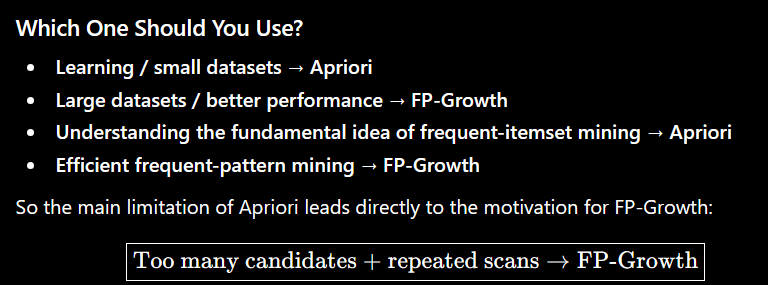


# 12. Apriori vs FP-Growth

Both **Apriori** and **FP-Growth** are algorithms used to find **frequent itemsets**.

The main difference is **how they search for frequent patterns**.

| Feature              | Apriori                           | FP-Growth                            |
| -------------------- | --------------------------------- | ------------------------------------ |
| Basic idea           | Generate candidates and test them | Build an FP-Tree and mine patterns   |
| Candidate generation | **Yes**                           | **No explicit candidate generation** |
| Database scans       | Multiple scans                    | Usually fewer scans                  |
| Speed                | Can become slow                   | Generally faster                     |
| Memory               | Can require large candidate sets  | Uses compressed FP-Tree              |
| Simplicity           | Easier to understand              | More complex                         |
| Best suited for      | Smaller/simple datasets           | Larger transaction datasets          |

### Key Difference

**Apriori:**

$$
\text{Generate Candidates}
\rightarrow
\text{Prune}
\rightarrow
\text{Count Support}
\rightarrow
\text{Repeat}
$$

**FP-Growth:**

$$
\text{Build FP-Tree}
\rightarrow
\text{Mine Frequent Patterns}
$$

# Quick Revision

# `02_Apriori.ipynb` — Complete Quick Recap

## 1. What is Apriori?

* Apriori is a **frequent itemset mining algorithm**.
* Used in **Association Rule Learning**.
* Its main job is to find **frequent itemsets**.
* Association rules are generated **after** finding frequent itemsets.

$$
\text{Transactions}
\rightarrow
\text{Frequent Itemsets}
\rightarrow
\text{Association Rules}
$$

---

## 2. Important Terms

* **Transaction** → one customer's collection of purchased items.
* **Item** → individual product.
* **Itemset** → collection of items.
* **Frequent Itemset** → itemset whose support ≥ minimum support.
* **Candidate Itemset** → itemset being considered for frequency.
* **Antecedent** → left side of rule.
* **Consequent** → right side of rule.

Example:

$$
\{Milk, Bread\} \rightarrow \{Butter\}
$$

* Antecedent = `{Milk, Bread}`
* Consequent = `{Butter}`

---

# 3. Three Main Rule Measures

### Support

How frequently an itemset occurs.

$$
Support(X)=
\frac{\text{Transactions containing }X}
{\text{Total transactions}}
$$

### Confidence

How often $Y$ occurs when $X$ occurs.

$$
Confidence(X\rightarrow Y)
=
\frac{Support(X\cup Y)}
{Support(X)}
$$

### Lift

Measures association relative to independence.

$$
Lift(X\rightarrow Y)
=
\frac{Confidence(X\rightarrow Y)}
{Support(Y)}
$$

Interpretation:

* Lift > 1 → positive association
* Lift = 1 → independent
* Lift < 1 → negative association

---

# 4. Apriori Principle

The most important idea:

> **If an itemset is infrequent, all of its supersets must also be infrequent.**

Example:

If:

$$
\{A,B\}
$$

is infrequent, then:

$$
\{A,B,C\},\{A,B,D\},\{A,B,C,D\}
$$

cannot be frequent.

Therefore:

$$
\boxed{
\text{Infrequent subset}
\rightarrow
\text{Prune all supersets}
}
$$

This is what makes Apriori practical.

---

# 5. Complete Apriori Steps

### Step 1 — Find 1-item candidates

$$
C_1
$$

Example:

$$
\{A\},\{B\},\{C\},\{D\}
$$

---

### Step 2 — Calculate support

Count how many transactions contain each candidate.

---

### Step 3 — Apply minimum support

Remove candidates below the threshold.

$$
C_1
\rightarrow
L_1
$$

where:

* $C$ = Candidate itemsets
* $L$ = Frequent itemsets

---

### Step 4 — Generate larger candidates

Use frequent itemsets from the previous level.

$$
L_1\rightarrow C_2
$$

Then:

$$
L_2\rightarrow C_3
$$

and so on.

---

### Step 5 — Prune candidates

Check whether **every $(k-1)$-subset** of a candidate is frequent.

If even one subset is infrequent:

$$
\text{Candidate}
\rightarrow
\text{Discard}
$$

---

### Step 6 — Count support again

Calculate support for remaining candidates.

$$
C_k
\rightarrow
L_k
$$

---

### Step 7 — Repeat

Continue until no new frequent itemsets can be generated.

$$
L_1
\rightarrow
L_2
\rightarrow
L_3
\rightarrow
\cdots
$$

---

# 6. Candidate Generation vs Pruning

These are different.

### Candidate Generation

Create possible larger itemsets.

$$
L_{k-1}
\rightarrow
C_k
$$

### Pruning

Remove candidates whose subsets are not frequent.

$$
C_k
\rightarrow
\text{Pruned }C_k
$$

### Support Counting

Calculate how frequently the remaining candidates occur.

$$
C_k
\rightarrow
L_k
$$

---

# 7. Minimum Support

Minimum support controls what counts as frequent.

If:

* Total transactions = 100
* Minimum support = 20%

Then minimum support count is:

$$
100\times0.20=20
$$

So an itemset must appear in **at least 20 transactions**.

### Effect

**Higher minimum support:**

$$
\text{Fewer itemsets}
\rightarrow
\text{More pruning}
\rightarrow
\text{Faster}
$$

**Lower minimum support:**

$$
\text{More itemsets}
\rightarrow
\text{Less pruning}
\rightarrow
\text{More computation}
$$

---

# 8. Example Flow

Suppose:

```text
Transactions
     ↓
C1
     ↓ support
L1
     ↓ candidate generation
C2
     ↓ prune + support
L2
     ↓ candidate generation
C3
     ↓ prune + support
L3
     ↓
Frequent Itemsets
```

Then:

```text
Frequent Itemsets
       ↓
Generate possible rules
       ↓
Calculate confidence
       ↓
Filter rules
       ↓
Check lift
       ↓
Final Association Rules
```

---

# 9. Rule Generation

From a frequent itemset:

$$
\{A,B,C\}
$$

possible rules include:

$$
A\rightarrow B,C
$$

$$
B\rightarrow A,C
$$

$$
A,B\rightarrow C
$$

$$
A,C\rightarrow B
$$

etc.

For an itemset containing $n$ items:

$$
\boxed{2^n-2}
$$

possible directional rules can be generated.

---

# 10. Python Implementation

### Find frequent itemsets

```python
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    df,
    min_support=0.4,
    use_colnames=True
)
```

Output:

```text
support    itemsets
0.8        {Milk}
0.6        {Milk, Bread}
...
```

### Generate rules

```python
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.7
)
```

Then commonly filter:

```python
rules[
    (rules["confidence"] >= 0.7) &
    (rules["lift"] > 1)
]
```

---

# 11. Apriori's Main Weakness

The core problem:

$$
\boxed{
\text{Many candidate itemsets}
+
\text{Repeated database scans}
}
$$

Especially when:

* Dataset is large
* Number of items is large
* Minimum support is low

This can make Apriori slow and memory-intensive.

---

# 12. Apriori vs FP-Growth

|                      | Apriori            | FP-Growth                        |
| -------------------- | ------------------ | -------------------------------- |
| Candidate generation | Yes                | No explicit candidate generation |
| Main structure       | Candidate itemsets | FP-Tree                          |
| Database scans       | Multiple           | Fewer                            |
| Speed                | Generally slower   | Generally faster                 |
| Simplicity           | Easier             | More complex                     |
| Large datasets       | Less suitable      | More suitable                    |

### One-line difference

$$
\boxed{
\text{Apriori = Generate + Prune + Count}
}
$$

$$
\boxed{
\text{FP-Growth = Compress + Mine}
}
$$

---

## Apriori in One Mental Picture

Remember this:

```text
TRANSACTIONS
     ↓
Generate C1
     ↓
Count Support
     ↓
Prune
     ↓
L1
     ↓
Generate C2
     ↓
Prune
     ↓
L2
     ↓
Generate C3
     ↓
Prune
     ↓
L3
     ↓
Repeat...
     ↓
FREQUENT ITEMSETS
     ↓
Generate Rules
     ↓
Confidence + Lift
     ↓
FINAL RULES
```

### The 5 things to remember for Apriori

**1. Frequent itemsets** → what we're finding
**2. Support** → is it frequent enough?
**3. Apriori Principle** → infrequent subset ⇒ prune supersets
**4. Candidate → Prune → Support → Repeat**
**5. Main weakness** → too many candidates + repeated scans
